# Measurement with Arbitrary Signals

For measurements in the seconds range, you can use either the [PogaJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.RampJob) or [RampJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.RampJob). These jobs work well for gradual signal changes and provide precise control over longer time periods.

However, for signals under one second, the [WaveJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.WaveJob) is your best choice due to the inherent dead times in other job types. The [WaveJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.WaveJob) is optimized for high-speed signal generation and measurement, making it perfect for applications that need rapid signal changes. It works similar to a [WAV file](https://en.wikipedia.org/wiki/WAV) format, allowing you to create complex, high-frequency waveforms with precise timing.

This flexibility lets you generate virtually any signal pattern you need, which is ideal for advanced testing scenarios like simulating real-world conditions or stress-testing components. With the [WaveJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.WaveJob), you can precisely control both the output data rate and value rate to meet your specific experimental requirements.

In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import EngFormatter
import numpy as np
import scipy.signal
import zahner_link as zl
import struct

def plot_dataset_tiu(dataset: zl.DcDataset):
    time = dataset.get_dc_track("time")
    voltage = dataset.get_dc_track("voltage")
    current = dataset.get_dc_track("current")

    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    (line1,) = ax1.plot(time, voltage, color="blue", label="Voltage")
    (line2,) = ax2.plot(time, current, color="red", label="Current")
    ax1.legend(handles=[line1, line2])

    ax1.xaxis.set_major_formatter(EngFormatter(unit="$s$"))
    ax1.yaxis.set_major_formatter(EngFormatter(unit="$V$"))
    ax1.set_xlabel("Time")
    ax1.set_ylabel("Voltage")
    ax1.grid()
    ax1.margins(0.01)
    ax2.xaxis.set_major_formatter(EngFormatter(unit="$s$"))
    ax2.yaxis.set_major_formatter(EngFormatter(unit="$A$"))
    ax2.set_xlabel("Time")
    ax2.set_ylabel("Current")
    ax2.grid()
    ax2.margins(0.01)

    fig.set_size_inches(18, 10)
    plt.show()
    return

link = zl.ZahnerLinkExc("localhost", "1994")
error: zl.ErrorObject = link.connect()

if not error:
    print("connected successfully")
else:
    print(f"failed to connect, status: {error.get_error_code_enum()}, message: {error.get_message_formatted()}")

switch_on_job = zl.control.SwitchOnJob(
    potentiostat="MAIN:1:POT",
    coupling=zl.PotentiostatCoupling.POTENTIOSTATIC,
    bias=0,
    voltage_range_index=0,
    compliance_range_index=0,
)
switch_off_job = zl.control.SwitchOffJob(potentiostat="MAIN:1:POT")
link.do_job(switch_on_job)

connected successfully


## Arbitrary Data Generation

The [WaveJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.WaveJob) operates entirely in either potentiostatic or galvanostatic mode, depending on which mode was active when the job started. Switching between these modes takes considerable time and isn't what this job is designed for.

Using the [WaveJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.WaveJob) is straightforward - you provide a Python list of points (`values`) and specify the frequency (`value_rate`) at which these points should be output. You can also set the `output_data_rate`, which determines how frequently measurements are taken and can differ from the `value_rate`.

### Voltage Pulses

Our first example demonstrates simple voltage pulse shapes that you can use as building blocks for your own custom pulse methods.

In [2]:
values = [0,1,-1,2,-2,3,-3,0]
value_rate = 100
output_data_rate = 10000

In this example, we've defined:
- A sequence of voltage values that alternates between positive and negative, increasing in magnitude
- A `value_rate` of 100 Hz, meaning each voltage point is held for 10 ms
- An `output_data_rate` of 10,000 Hz, which means we'll collect 100 measurement points per output value

For the measurement, the Rendles circuit of the dummy cell is measured.

Now we'll execute the job and plot the results:

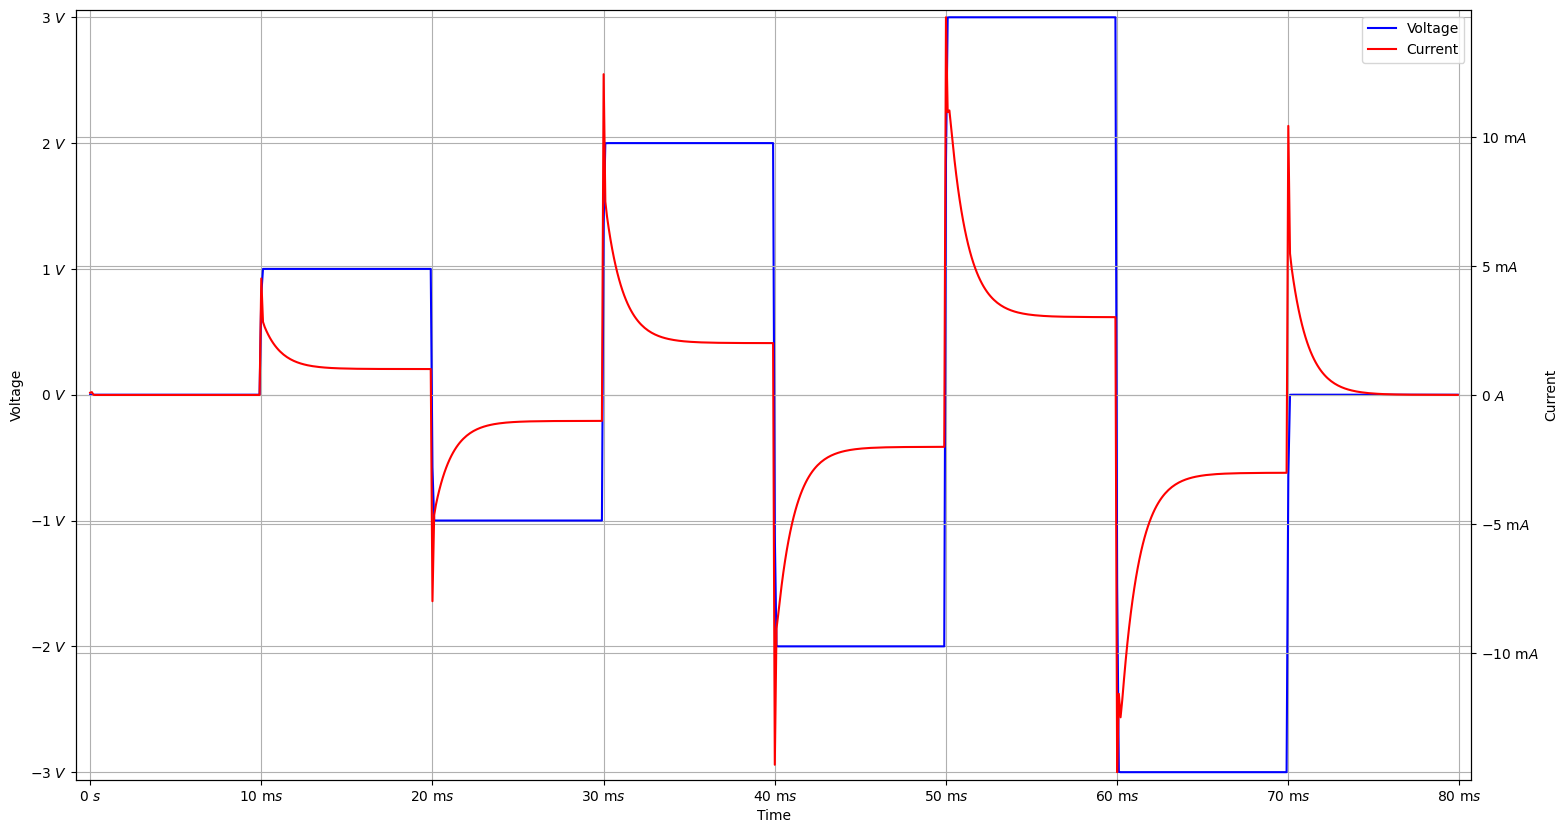

In [3]:
wave_job = zl.meas.WaveJob(
    output_data_rate=output_data_rate,
    value_rate=value_rate,
    current_range=0.01,
    values=values,
)

link.do_job(wave_job)
plot_dataset_tiu(link.get_job_result_data(wave_job))

### Composite Triangular Waveform

This next example shows how to generate a more complex waveform consisting of multiple segments, including triangular waves with different amplitude ranges. This type of custom pattern allows for precise control over the potential applied to an electrochemical cell over time.

The waveform we'll create has four distinct segments:
1. An initial 1-second period at constant 0V
2. Three cycles of triangular waves oscillating between 0V and +1V
3. Four cycles of triangular waves oscillating between 0V and -1V
4. A final 1-second period at constant 0V

We'll define parameters like sampling rate, frequency, and segment durations. Then we'll generate each segment using [numpy](https://numpy.org/) and [scipy.signal.sawtooth](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.sawtooth.html#scipy.signal.sawtooth) (adjusted to create triangular waves) before combining them into a complete waveform.

Since this signal is longer, it is not passed directly as an array but with a resource. This has the advantage that the same wave can be executed multiple times as a resource.

**Applications in Electrochemistry:**

These arbitrary waveforms have several valuable uses in electrochemistry:

* **Custom Voltammetry**: Create specific potential patterns beyond standard linear or cyclic voltammetry to target particular redox events
* **Advanced Pulse Techniques**: Design complex pulse sequences for techniques like differential pulse voltammetry with custom modifications
* **Material Testing**: Subject materials (like battery electrodes or sensors) to specific potential profiles that simulate real-world conditions
* **Reaction Mechanism Studies**: Apply precisely timed potential sequences to isolate or enhance specific reaction steps
* **Sensor Development**: Evaluate how electrochemical sensors respond to complex input signals

In [4]:
rate = 50  # Samples per second
frequency = 1  # Sawtooth frequency in Hz

# Define segment durations
duration1 = 1.0  # seconds of 0V at the start
duration2 = 3 / frequency  # seconds for 3 periods (0 to 1V)
duration3 = 4 / frequency  # seconds for 4 periods (0 to -1V)
duration4 = 1.0  # seconds of 0V at the end

# Calculate total duration
total_duration = duration1 + duration2 + duration3 + duration4

# Calculate number of points per segment
num_points1 = int(duration1 * rate)
num_points2 = int(duration2 * rate)
num_points3 = int(duration3 * rate)
num_points4 = int(duration4 * rate)
total_points = num_points1 + num_points2 + num_points3 + num_points4

# Generate segment 1: 0V
segment1 = np.zeros(num_points1)

# Generate segment 2: 3 periods, 0V to 1V
t2 = np.linspace(0, duration2, num_points2, endpoint=False)
tri_wave_raw_2 = scipy.signal.sawtooth(2 * np.pi * frequency * t2, width=1)
segment2 = (tri_wave_raw_2 + 1) / 2 

# Generate segment 3: 4 periods, 0V to -1V
t3 = np.linspace(0, duration3, num_points3, endpoint=False)
tri_wave_raw_3 = scipy.signal.sawtooth(2 * np.pi * frequency * t3, width=1)
segment3 = (tri_wave_raw_3 - 1) / 2 

# Generate segment 4: 0V
segment4 = np.zeros(num_points4)

# Concatenate the segments
triangular_wave = np.concatenate((segment1, segment2, segment3, segment4))

values_triangular = triangular_wave.tolist()

First, the generated signal is stored in a binary array with 64-bit floating point values in little endian format. This binary array is then appended to the resource.

In [5]:
ressource_array = link.create_resource(zl.ResourceTypeEnum.WAVE, "wave_test_data")
if not ressource_array.is_valid():
    print("Failed to create resource")

binary_values = bytearray()
for value in values_triangular:
    binary_values.extend(struct.pack('<d', value))
appending_success = link.append_to_resource(ressource_array, binary_values)
if not appending_success:
    print("Failed to append data to resource")

Failed to append data to resource


Then, the ID of the resource is passed to [WaveFileJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.WaveFileJob) instead of the values, and the job is executed as usual.

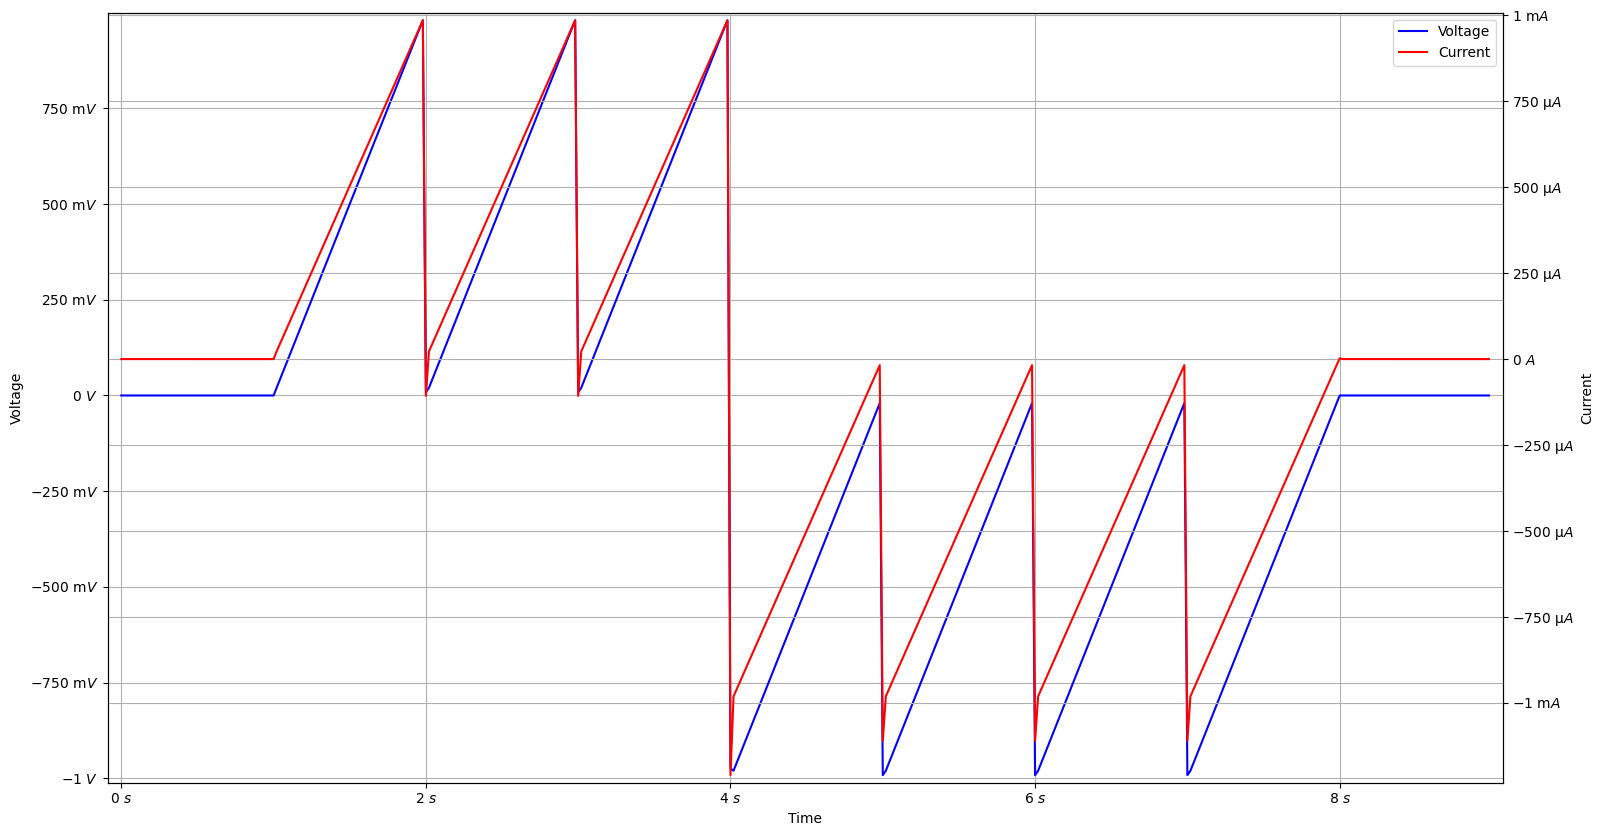

In [6]:
wave_job_triangular = zl.meas.WaveFileJob(
    output_data_rate=rate,
    value_rate=rate,
    current_range=0.001,
    resource_id=ressource_array.get_id(),
)

link.do_job(wave_job_triangular)
plot_dataset_tiu(link.get_job_result_data(wave_job_triangular))


However, there is still the option of writing the values to a file and then generating the resource from a local file.

This has the advantage that if I only want to generate a waveform once and then distribute it to different clients, I can do so.

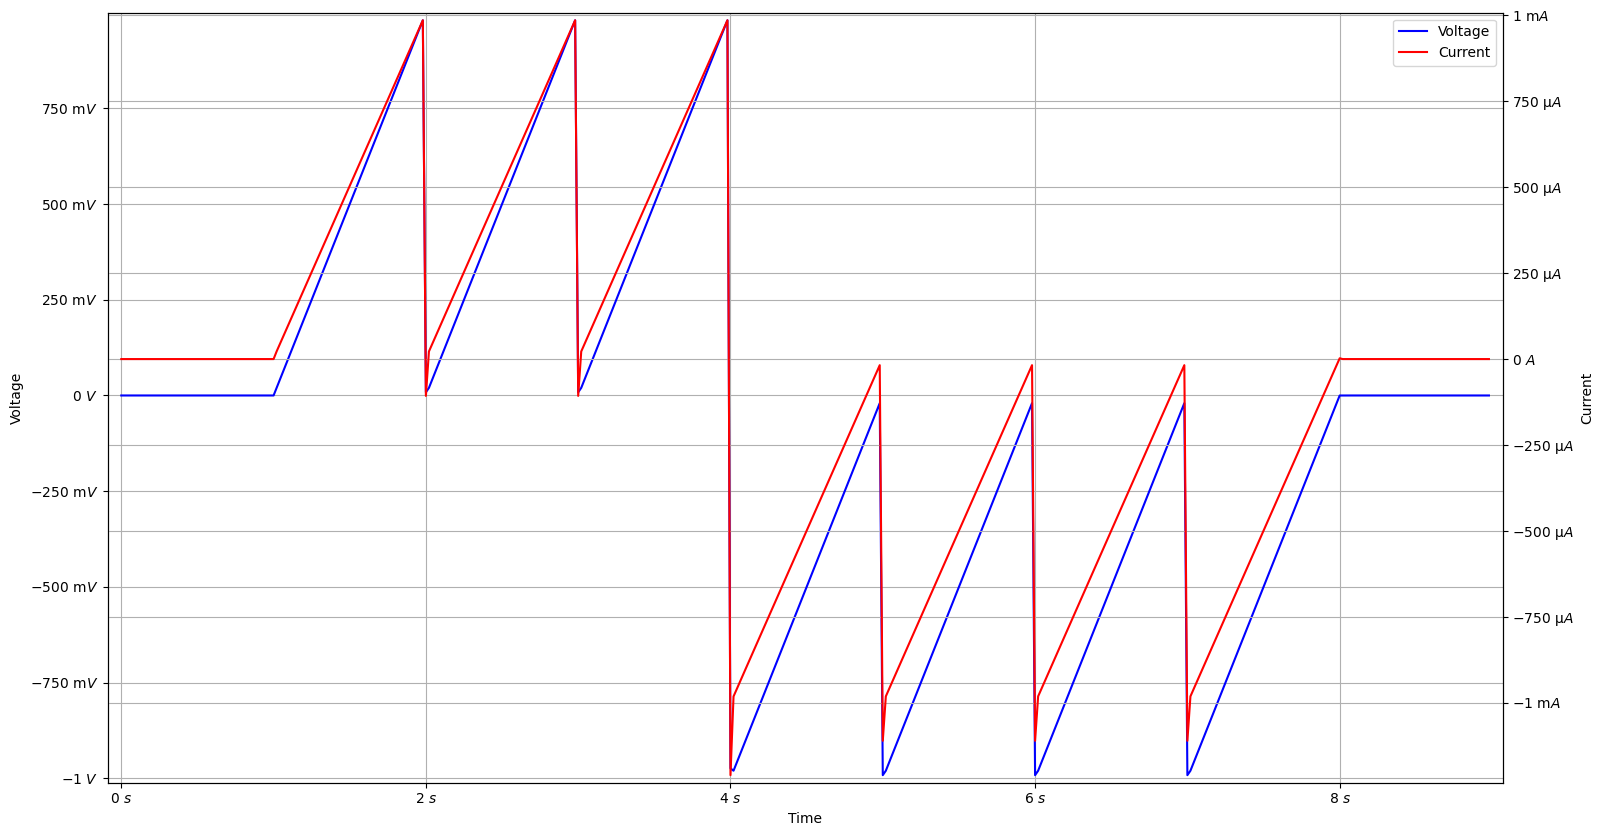

In [7]:
filename = "wave_values.bin"
with open(filename, "wb") as f:
    f.write(binary_values)

ressource_file = link.create_resource_from_file(zl.ResourceTypeEnum.WAVE, filename, "wave_from_file")
if not ressource_file.is_valid():
    print("Failed to create resource from file")
    
wave_job_triangular_file = zl.meas.WaveFileJob(
    output_data_rate=rate,
    value_rate=rate,
    current_range=0.001,
    resource_id=ressource_file.get_id(),
)

link.do_job(wave_job_triangular_file)
plot_dataset_tiu(link.get_job_result_data(wave_job_triangular_file))

### Custom Algorithm Development

For example, tests could be performed using arbitrary voltage signals to calculate impedance.

In this case, a multisine signal is generated in Python and output. However, it should be noted that no AC calibration data exists for this.

In this example, 31 waves ranging from 100 mHz to 2 kHz, each with an amplitude of 5 mV, are combined.

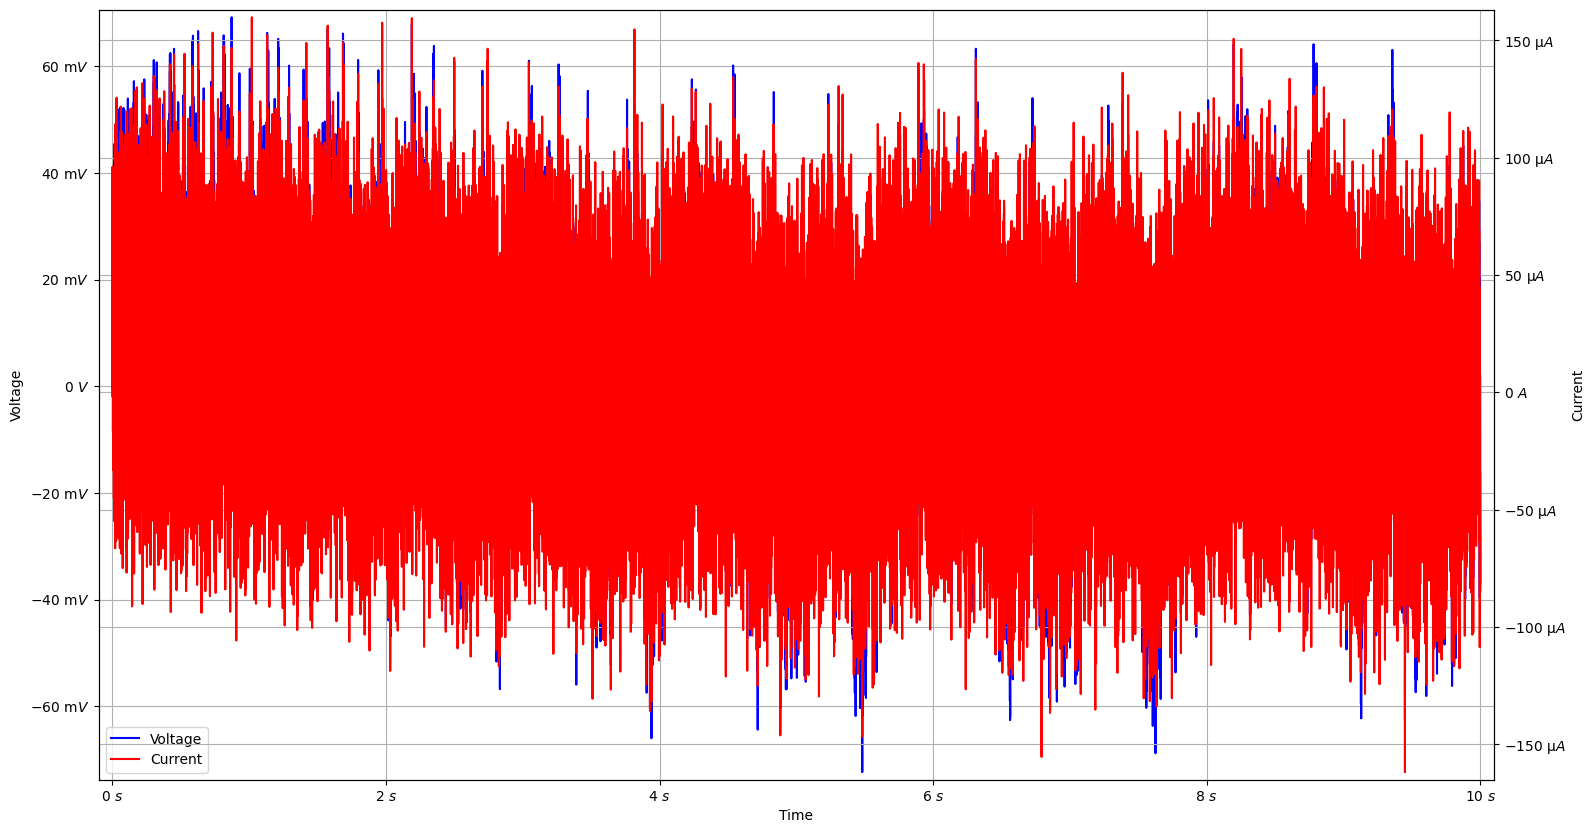

In [8]:
duration = 10
sample_rate = 10e3
frequencies = np.logspace(np.log10(0.1), np.log10(2e3), num=31)
amplitudes = [0.005 for i in frequencies]

def generate_combined_sine_wave(
    amplitudes, frequencies, duration=1.0, sample_rate=1000
):
    """
    Generate a combined sine wave signal from multiple frequency components.
    
    This function creates a composite waveform by summing multiple sine waves,
    each with its own amplitude and frequency. This is useful for creating
    multisine signals for impedance spectroscopy or other electrochemical
    measurements.
    
    :param amplitudes: List of amplitudes for each frequency component. Must have the same length as frequencies.
    :param frequencies: List of frequencies in Hz for each sine wave component. Must have the same length as amplitudes.
    :param duration: Duration of the signal in seconds
    :param sample_rate: Sampling rate in Hz
    :returns: tuple containing time array in seconds and combined sine wave signal
    """
    t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
    combined_wave = np.zeros_like(t)

    for amplitude, frequency in zip(amplitudes, frequencies):
        combined_wave += amplitude * np.sin(2 * np.pi * frequency * t)

    return t, combined_wave

t, wave = generate_combined_sine_wave(
    amplitudes, frequencies, duration, sample_rate
)

wave_job_sine = zl.meas.WaveJob(
    output_data_rate=sample_rate,
    value_rate=sample_rate,
    current_range=0.01,
    values=wave,
)

link.do_job(wave_job_sine)
wave_job_sine_data = link.get_job_result_data(wave_job_sine)
plot_dataset_tiu(wave_job_sine_data)

xml_measurement = zl.xml.Measurement(wave_job_sine_data)
exporter = zl.xml.ZXmlExporter()
exporter.set_compact_xml(False)
exporter.save_as_file_standalone(xml_measurement, "wave_job_sine.zmx")

del wave_job_sine_data

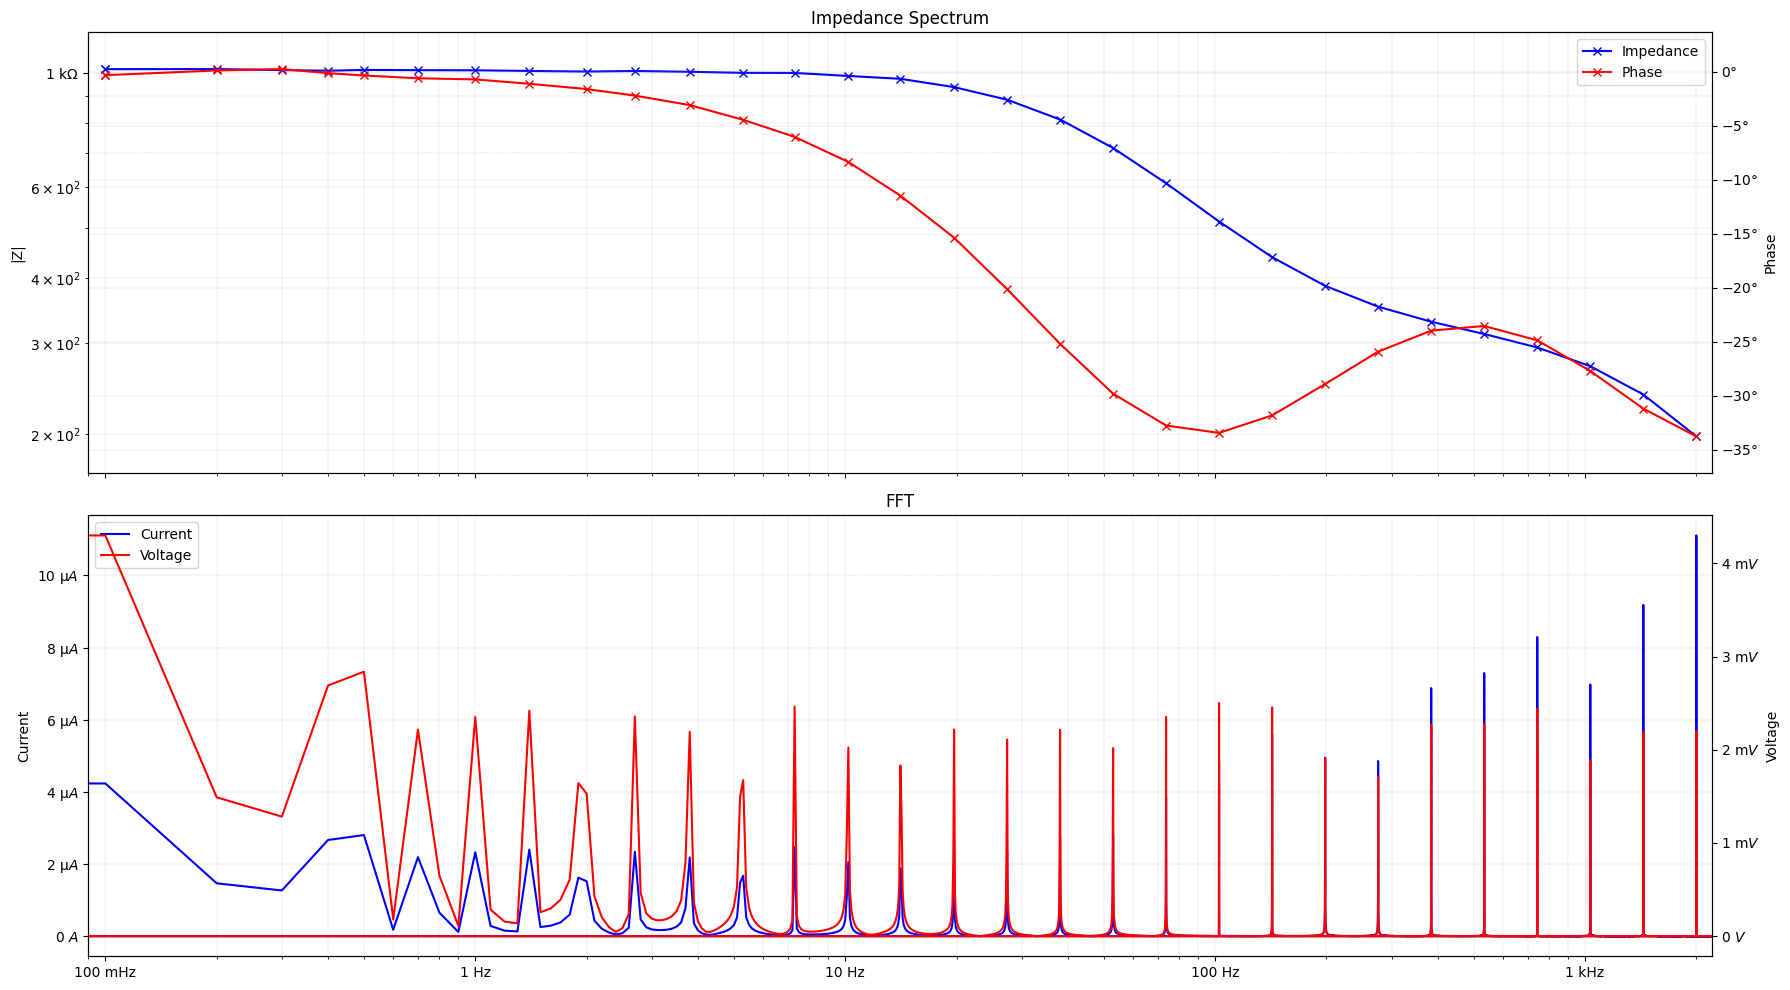

In [9]:
importer = zl.xml.ZXmlImporter()
xml_measurement = importer.import_from_file_as_measurement("wave_job_sine.zmx")
wave_job_sine_data = xml_measurement.get_datasets()[0]

# Extract measurement data from the WaveJob result
time = wave_job_sine_data.get_dc_track("time")
voltage = wave_job_sine_data.get_dc_track("voltage")
current = wave_job_sine_data.get_dc_track("current")

# Perform FFT on voltage and current signals
n = len(time)
voltage_fft = np.fft.fft(voltage) / n
current_fft = np.fft.fft(current) / n

# Generate frequency array and calculate impedance from FFT results
freq = np.fft.fftfreq(n, d=(time[1] - time[0]))
impedance = voltage_fft / current_fft

# Filter impedance data to match the original excitation frequencies
filtered_indices = [np.argmin(np.abs(freq - f)) for f in frequencies]
filtered_freq = freq[filtered_indices]
filtered_impedance = impedance[filtered_indices]

# Create subplot layout for impedance spectrum and FFT plots
fig, (impedance_ax, i_fft_ax) = plt.subplots(nrows=2, sharex=True)
phase_ax = impedance_ax.twinx()
u_fft_ax = i_fft_ax.twinx()

# Plot impedance magnitude and phase
impedance_ax.set_title("Impedance Spectrum")
(impedance_line,) = impedance_ax.loglog(
    filtered_freq,
    np.absolute(filtered_impedance),
    marker="x",
    color="blue",
    label="Impedance",
)

(phase_line,) = phase_ax.semilogx(
    filtered_freq,
    np.angle(filtered_impedance, deg=True),
    marker="x",
    color="red",
    label="Phase",
)

# Format impedance plot axes and styling
impedance_ax.yaxis.set_major_formatter(EngFormatter(unit=r"$\Omega$"))
impedance_ax.xaxis.set_major_formatter(EngFormatter(unit="Hz"))
impedance_ax.set_ylabel(r"|Z|")
impedance_ax.grid(which="both",linestyle="dashed", linewidth=0.2)
impedance_ax.set_xlim(np.min(filtered_freq)*0.9, np.max(filtered_freq)*1.1)
margin = 0.1
impedance_ax.margins(margin)

phase_ax.yaxis.set_major_formatter(EngFormatter(unit="$°$", sep=""))
phase_ax.xaxis.set_major_formatter(EngFormatter(unit="Hz"))
phase_ax.set_ylabel("Phase")
phase_ax.grid(which="both",linestyle="dashed", linewidth=0.2)
phase_ax.margins(margin)
impedance_ax.legend(handles=[impedance_line, phase_line])

# Plot FFT spectra of current and voltage
i_fft_ax.set_title("FFT")
(i_line,) = i_fft_ax.semilogx(freq, np.abs(current_fft), color="blue", label="Current")
(u_line,) = u_fft_ax.semilogx(freq, np.abs(voltage_fft), color="red", label="Voltage")
i_fft_ax.legend(handles=[i_line, u_line])
i_fft_ax.grid(which="both",linestyle="dashed", linewidth=0.2)
i_fft_ax.set_ylabel(r"Current")
i_fft_ax.xaxis.set_major_formatter(EngFormatter(unit="Hz"))
i_fft_ax.yaxis.set_major_formatter(EngFormatter(unit="$A$"))
u_fft_ax.set_ylabel(r"Voltage")
u_fft_ax.xaxis.set_major_formatter(EngFormatter(unit="Hz"))
u_fft_ax.yaxis.set_major_formatter(EngFormatter(unit="$V$"))
fig.set_size_inches(18, 10)
fig.tight_layout()
plt.show()

## Switching off and disconnecting from the IM7

After completing our experiments, we need to properly shut down the system by switching off the potentiostat and disconnecting from the device.

In [10]:
link.do_job(switch_off_job)
link.disconnect()